Case Cientista de Dados


Os dados abaixo representam o histórico de dois 
anos (2015-2017) de uma empresa que oferece 
serviço de streaming de música baseado em 
assinatura.
Quando os usuários se inscrevem no serviço, eles 
podem optar por renovar o serviço manualmente 
ou renovar automaticamente. Os usuários podem 
cancelar ativamente sua associação a qualquer 
momento.

Para esse cenário, temos os seguintes desafios:


A) Sabendo que existe a seguinte ação de retenção 
para clientes: Quando detectamos que um cliente 
não renova a assinatura, oferecemos 3 meses 
grátis. Porém, identificamos que essa ação é muito 
reativa e entendemos que uma abordagem 
proativa seria mais efetiva.
Sendo assim, é proposto que você crie um modelo 
classificador para prever clientes que serão churn 3 
meses no futuro (ou seja, clientes que possuem 
assinatura ativa no período analisado e 3 meses 
depois desse período ele não é mais ativo, ou 
porque cancelou ou não renovou a assinatura) e 
indique os clientes que serão direcionados para a 
ação de forma proativa.


Assumindo que, usando a ação de forma proativa, 
50% dos clientes que iriam cancelar (Verdadeiro 
Positivo) respondem de forma positiva e 
continuam ativos por mais um ano, qual sua 
avaliação sobre sua solução?
Mínimo esperado:
- Criação de target;
- Feature Engineering;
- Feature Selection;
- Predictive Modeling;
- Quantidade de clientes retidos e resultado 
financeiro da ação.

B) O comitê executivo precisa de visibilidade de 
rentabilidade das assinaturas dos clientes para 
antecipar tendencias.
O custo é dado por:
C(u,t)=50+0.0051u+0.0001t
Em que u é a quantidade de músicas únicas que o 
cliente ouviu no mês de referência e t é o tempo 
total em segundos que o cliente ouviu no mesmo 
período;
Desenvolva um modelo para estimar a Margem 
Líquida (Preço – Custo) do produto e avalie sua 
performance em M+1
A partir do métrica escolhida, o que você pode 
concluir sobre o resultados?

Mínimo esperado:
- Criação de target usando a função dada;
- Feature Engineering;
- Feature Selection;
- Predictive Modeling;
- Conclusão do resultado (métrica escolhida, 
intervalo de confiança, etc)

C) Considerando o problema escolhido anteriormente (Churn ou Rentabilidade), realize  uma análise não-supervisionada dos clientes com  objetivo de aprofundar a compreensão sobre  características deles.

Algumas sugestões de possíveis direcionamentos 
para sua análise:
a) Análise de clientes com diferentes perfis de uso 
da plataforma, com as variadas estimações de 
rentabilidade/churn;
b) Análise de perfis de clientes com diferentes 
volatilidade/incerteza nas respostas de 
rentabilidade/churn;
c) Análise de erros sistemáticos cometidos pelos 
modelos do case supervisionado;
d) Análise da variação temporal no 
comportamento dos clientes da base


Para ter acesso as bases e resolver o case, clique 
abaixo:
Kaggle
https://www.kaggle.com/datasets/gcenachi/casedata-master-
Dicionário de dados:
User log data has been aggregated and converted 
to parquet format


# Case escolhido: Churn

# Objetivo

Este notebook tem como objetivo um modelo de predição de churn usando ciências de dados em uma empresa de streaming de música, afim de ser avaliado por experts de ciências de dados do banco Santander. Cada vez mais as empresas estão investindo em ferramentas e profissionais com capacidades analíticas e que trabalham com dados reais para gerarem valor ao seu negócio.

No final, todas as análises e aplicação do modelo que serão explicados durante este notebook resultarão em uma informação muito relevante para o negócio, que será o quanto de economia teremos após aplicação do modelo em produção.

Para isso, Seguirei com um passo a passo para testar modelos de classificação

Neste notebook :
1. Analisar as bases: granularidade, unicidade de variaveis, relações entre elas
2. tratar inconsistências: campos nulos, valores que não fazem sentido ex. idade negativa
3. Descobrir como elas se relacionam, quais são as regras de negócio envolvidas para montar o consentio de churn.
4. Criar feature com a Regra de churn (target) 3 meses no futuro
5. Criar novas features 
6. Geração da base completa a ser usada pelo modelo

No notebook de modelo https://www.kaggle.com/code/viniciusdomingues/datamaster-vinicius-modelo:

7. amostrar a base e separar base em treino , teste e validaçao
8. Seleçao de Features
9. Escolher métricas de sucesso do modelo 
10. Testar modelos de Classificação e seus hiper parametros e escolher o melhor
11. Resultados para o negócio. Quanto vale a solução?
12. Usar metodos não supervisionados para saber mais sobre os clientes churn

Escolhi separar os ETL e modelo porque é o comum no ambiente profissional e foi mais performático. Para fazer os testes com o modelo, usei o output deste notebook. Não precisava gastar recurso computacional toda a vez para criar a mesma base sempre que fazia alguma alteração no modelo.



Vou usar pyspark para o primeiro tratamento e analises das bases, pois além de ser ótima para trabalhar com grandes volumes de dados, é uma linguagem que domino e é amplamente utilizada ao se trabalhar com dados em ambiente produtivo de cloud.

# Importando bibliotecas

In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 3.8 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.3-py2.py3-none-any.whl size=317840628 sha256=683b56591fb9168c4e474ced2e9684e01be96610a2be237bca6cc710b7baeb4e
  Stored in directory: /root/.cache/pip/wheels/1b/3a/92/28b93e2fbfdbb07509ca4d6f50c5e407f48dce4ddbda69a4ab
Successfully built pyspark


In [2]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/part-00069-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet
/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/.part-00077-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet.crc
/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/.part-00003-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet.crc
/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/.part-00082-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet.crc
/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/part-00034-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet
/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/.part-00005-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet.crc
/kaggle/input/datamaster-tabela-completa/tabela_completa_v3.parquet/part-00088-cdef4de8-f341-44e0-b3ca-b6c7613a4c2f-c000.snappy.parquet
/kaggle/input/datamaster-tab

In [3]:
# Iniciando sessão spark
spark = (
    SparkSession.builder
        .appName('Data Master Vinicius v0')
        .config("spark.driver.memory", "4g")  # Ajuste para até 6g se precisar, dependendo do seu uso
        .config("spark.executor.memory", "4g") # Equilibrar a memória do executor
        .config("spark.executor.cores", "2") # O Kaggle geralmente oferece 2 CPUs
        .config("spark.sql.shuffle.partitions", "200") 
        .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR") 

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/11/22 14:10:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Importando bases

In [4]:
members = spark.read.parquet(
    '/kaggle/input/case-data-master-2024/members.parquet'
)
members.printSchema()
##################################################################################

user_logs = spark.read.parquet(
    '/kaggle/input/case-data-master-2024/user_logs.parquet'
)
user_logs.printSchema()

##################################################################################

transactions = spark.read.parquet(
    '/kaggle/input/case-data-master-2024/transactions.parquet'
)

transactions.printSchema()

root
 |-- msno: string (nullable = true)
 |-- safra: string (nullable = true)
 |-- registration_init_time: string (nullable = true)
 |-- city: string (nullable = true)
 |-- bd: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: string (nullable = true)
 |-- is_ativo: integer (nullable = true)

root
 |-- msno: string (nullable = true)
 |-- safra: integer (nullable = true)
 |-- num_25: double (nullable = true)
 |-- num_50: double (nullable = true)
 |-- num_75: double (nullable = true)
 |-- num_985: double (nullable = true)
 |-- num_100: double (nullable = true)
 |-- num_unq: double (nullable = true)
 |-- total_secs: double (nullable = true)

root
 |-- msno: string (nullable = true)
 |-- payment_method_id: string (nullable = true)
 |-- payment_plan_days: string (nullable = true)
 |-- plan_list_price: string (nullable = true)
 |-- actual_amount_paid: string (nullable = true)
 |-- is_auto_renew: string (nullable = true)
 |-- transaction_date: string (nullabl

# Discovery das bases e primeiros Tratamentos

A ideia é estudar as informações contidas nas bases. Vou verificar nulos, observações que não fazem sentido criar e transformar campos para faciitar a manipulação

## Members
User information. Note that not every user in the dataset is available.

• msno

• city

• bd: age. Note: this column has outlier values ranging from -7000 to 2015, please use your judgement.

• gender

• registered_via: registration method

• registration_init_time: format %Y%m%d

### **EDA da members:**
* Genero é nulo para quase metade da base - Além de ser uma informação discriminatória, é uma variável incompleta; vou descartá-la
* members só tem dados de 2016, como a target é feita com essa base, teremos apenas esse ano para usar em treino, teste e validação
* As city e registered_via, apesar de serem numeros, tem baixa variabilidade, possibilitando encoding one-hot encoding
* Idade: Essa variável é problemática.Possui valores descondizentes com a realidade e o próprio case avisa que há outliers. Fiz a análise de outliers e mesmo após substituindo pela mediana continuavam com valores que não fazem sentido (menores que 0 e maiores que 122). Portanto, para não excluí-la do modelo por enquanto, substitui eses valores pela mediana também.
    * Além disso, como ela também é discriminatória, transformei ela em uma anonimizada por faixa:
        * Infantil: De 0 a 12 anos = 1
        * Adolescente: De 13 a 17 anos = 2
        * Jovem Adulto 18 a 30 anos = 3
        * Adulto: De 31 a 64 anos = 4
        * Idoso: De 65 anos ou mai = 5

In [5]:
members.dtypes

[('msno', 'string'),
 ('safra', 'string'),
 ('registration_init_time', 'string'),
 ('city', 'string'),
 ('bd', 'string'),
 ('gender', 'string'),
 ('registered_via', 'string'),
 ('is_ativo', 'int')]

In [6]:
members.show(3,vertical = True)

-RECORD 0--------------------------------------
 msno                   | +++snpr7pmobhLKUg... 
 safra                  | 201612               
 registration_init_time | 20140927             
 city                   | 1                    
 bd                     | 0                    
 gender                 | NULL                 
 registered_via         | 7                    
 is_ativo               | 1                    
-RECORD 1--------------------------------------
 msno                   | ++/AwGzubug3gT6J+... 
 safra                  | 201607               
 registration_init_time | 20150322             
 city                   | 1                    
 bd                     | 0                    
 gender                 | NULL                 
 registered_via         | 9                    
 is_ativo               | 0                    
-RECORD 2--------------------------------------
 msno                   | ++/Gw1B9K+XOlB3hL... 
 safra                  | 201601        

In [7]:
members.describe().show(vertical = True)

-RECORD 0--------------------------------------
 summary                | count                
 msno                   | 63867246             
 safra                  | 63867246             
 registration_init_time | 63867246             
 city                   | 63867246             
 bd                     | 63867246             
 gender                 | 25657069             
 registered_via         | 63867246             
 is_ativo               | 63867246             
-RECORD 1--------------------------------------
 summary                | mean                 
 msno                   | NULL                 
 safra                  | 201606.90368996028   
 registration_init_time | 2.0140061722392727E7 
 city                   | 4.369941346774214    
 bd                     | 11.430160210759675   
 gender                 | NULL                 
 registered_via         | 5.455677343594869    
 is_ativo               | 0.17603491154135564  
-RECORD 2-------------------------------

In [8]:
## contar unicidade das variveis
for c in members.columns:
    members.agg(countDistinct(c)).withColumn("coluna", lit(c)).show()

+--------------------+------+
|count(DISTINCT msno)|coluna|
+--------------------+------+
|             6287789|  msno|
+--------------------+------+



+---------------------+------+
|count(DISTINCT safra)|coluna|
+---------------------+------+
|                   12| safra|
+---------------------+------+



+--------------------------------------+--------------------+
|count(DISTINCT registration_init_time)|              coluna|
+--------------------------------------+--------------------+
|                                  4663|registration_init...|
+--------------------------------------+--------------------+



+--------------------+------+
|count(DISTINCT city)|coluna|
+--------------------+------+
|                  21|  city|
+--------------------+------+



+------------------+------+
|count(DISTINCT bd)|coluna|
+------------------+------+
|               385|    bd|
+------------------+------+



+----------------------+------+
|count(DISTINCT gender)|coluna|
+----------------------+------+
|                     2|gender|
+----------------------+------+



+------------------------------+--------------+
|count(DISTINCT registered_via)|        coluna|
+------------------------------+--------------+
|                            17|registered_via|
+------------------------------+--------------+



+------------------------+--------+
|count(DISTINCT is_ativo)|  coluna|
+------------------------+--------+
|                       2|is_ativo|
+------------------------+--------+



Verificando os casos de outlier na variavel idade - A idade traz uma carga de comportamento para o modelo, como facilidade com tecnologia, por isso tratarei os outliers substituindo pela mediana, já que é uma medida pouco afetada por outliers.Depois, para não haver discriminação,vou usar a variavel  transformando em uma categórica faixa_idade sendo:
* Infantil: De 0 a 12 anos = 1
* Adolescente: De 13 a 17 anos = 2
* Jovem Adulto 18 a 30 anos = 3
* Adulto: De 31 a 64 anos = 4
* Idoso: De 65 anos ou mai = 5

Após pesquisas vi que a pessoa mais idosa do mundo tem 122 anos, fiz aguns testes posteriormente que 

In [9]:

# 1. Calcular Q1, Q3 e o IQR
members = members.withColumn("bd", col("bd").cast("float"))
Q1 = members.approxQuantile("bd", [0.25], 0.01)[0] # 25º percentil (1º quartil)
Q3 = members.approxQuantile("bd", [0.75], 0.01)[0] # 75º percentil (3º quartil)
IQR = Q3 - Q1

# Definir os limites para identificar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Contar quantos outliers existem
outliers_count = members.filter((col("bd") < lower_bound) | ((col("bd")> upper_bound))).count()
print(f"Número de outliers: {str(outliers_count)}")

# 3. Calcular a mediana
median = members.approxQuantile("bd", [0.5], 0.01)[0]

# 4. Substituir os outliers pela mediana
members =( 
    members
    .withColumn("bd", when((col("bd") < lower_bound) | (col("bd") > upper_bound), median).otherwise(col("bd"))
    )
)



Número de outliers: 336544


In [10]:
## a variavel BD que é a idade, possui valores que não fazem sentido, vamos ver quantos
teste_idade = (
    members
    .withColumn("erro_bd_flag", when((col("bd")>=122) | (col("bd")<0), lit(True)).otherwise(False))
    .groupBy("erro_bd_flag")
    .agg(count(lit(1)))
    .orderBy("erro_bd_flag")
)
teste_idade.show()

##Alguns casos outliers, corrobora para usar modelos que são robustos a esse tipo de caso como os baseados em arvores

+------------+--------+
|erro_bd_flag|count(1)|
+------------+--------+
|       false|63866946|
|        true|     300|
+------------+--------+



In [11]:
members = (
    members
    .withColumn("bd", when((col("bd") < 0) | (col("bd") >= 122), median).otherwise(col("bd")))
    .withColumn("faixa_idade", expr("""
                                    case when bd between 0 and 12 then 1
                                    when bd between 13 and 17 then 2
                                    when bd between 18 and 30 then 3
                                    when bd between 30 and 64 then 4
                                    else 5
                                    end
                                    """))
)

## User_logs
daily user logs describing listening behaviors of a user. Data collected until 3/31/2017.

 • msno: user id

 • date: format %Y%m%d

 • num_25: # of songs played less than 25% of the song length

 • num_50: # of songs played between 25% to 50% of the song length

 • num_75: # of songs played between 50% to 75% of of the song length

 • num_985: # of songs played between 75% to 98.5% of the song length

 • num_100: # of songs played over 98.5% of the song length

 • num_unq: # of unique songs played

 • total_secs: total seconds played

### **EDA da user_logs:**
* Variaveis todas numericas
* total_secs tem valores negativos, o que não faz sentido pelo negócio. Existem 42 mil valores negativos, o que 0.1% da base Avaliando, existem poucos mas impactam diretamente a média, o que quer dizer que sao valores negativos altos. Tomei a decisão de jogar esses valores para 0.
* Há oportunidade de entender a variação de um mês para o outro assim como o histório do cliente. Informações que podem ser relevantes para o churn, ex.: pessoas que estão consumindo cada vez menos musicas até o final podem se tornar churn

In [12]:
user_logs.show(3,vertical = True)


-RECORD 0--------------------------
 msno       | SwlrSivYHoKF9V5wm... 
 safra      | 201701               
 num_25     | 121.0                
 num_50     | 28.0                 
 num_75     | 14.0                 
 num_985    | 29.0                 
 num_100    | 704.0                
 num_unq    | 827.0                
 total_secs | 184606.903           
-RECORD 1--------------------------
 msno       | rE5wSmHEF1Dhu55zh... 
 safra      | 201605               
 num_25     | 26.0                 
 num_50     | 2.0                  
 num_75     | 5.0                  
 num_985    | 6.0                  
 num_100    | 462.0                
 num_unq    | 256.0                
 total_secs | 119439.485           
-RECORD 2--------------------------
 msno       | hx+cyaQ/Jcdr/Z5fo... 
 safra      | 201611               
 num_25     | 161.0                
 num_50     | 71.0                 
 num_75     | 49.0                 
 num_985    | 34.0                 
 num_100    | 668.0         

In [13]:
user_logs.describe().show(vertical =True, truncate = False)

-RECORD 0--------------------------------------------------
 summary    | count                                        
 msno       | 26758971                                     
 safra      | 26758971                                     
 num_25     | 26758971                                     
 num_50     | 26758971                                     
 num_75     | 26758971                                     
 num_985    | 26758971                                     
 num_100    | 26758971                                     
 num_unq    | 26758971                                     
 total_secs | 26758971                                     
-RECORD 1--------------------------------------------------
 summary    | mean                                         
 msno       | NULL                                         
 safra      | 201572.0403868669                            
 num_25     | 95.42601163549973                            
 num_50     | 24.03566975725636         

In [14]:
user_logs.filter(col("total_secs")<0).count()

42346

In [15]:
user_logs = user_logs.withColumn("total_secs",expr("case when total_secs < 0 then 0 else total_secs end "))

In [16]:
## contar unicidade das variveis
for c in user_logs.columns:
    user_logs.agg(countDistinct(c)).withColumn("coluna", lit(c)).show()

+--------------------+------+
|count(DISTINCT msno)|coluna|
+--------------------+------+
|             5234111|  msno|
+--------------------+------+



+---------------------+------+
|count(DISTINCT safra)|coluna|
+---------------------+------+
|                   26| safra|
+---------------------+------+



+----------------------+------+
|count(DISTINCT num_25)|coluna|
+----------------------+------+
|                  4891|num_25|
+----------------------+------+



+----------------------+------+
|count(DISTINCT num_50)|coluna|
+----------------------+------+
|                  1587|num_50|
+----------------------+------+



+----------------------+------+
|count(DISTINCT num_75)|coluna|
+----------------------+------+
|                   986|num_75|
+----------------------+------+



+-----------------------+-------+
|count(DISTINCT num_985)| coluna|
+-----------------------+-------+
|                   2509|num_985|
+-----------------------+-------+



+-----------------------+-------+
|count(DISTINCT num_100)| coluna|
+-----------------------+-------+
|                  13047|num_100|
+-----------------------+-------+



+-----------------------+-------+
|count(DISTINCT num_unq)| coluna|
+-----------------------+-------+
|                   8593|num_unq|
+-----------------------+-------+



+--------------------------+----------+
|count(DISTINCT total_secs)|    coluna|
+--------------------------+----------+
|                  23985003|total_secs|
+--------------------------+----------+



## Transactions
transactions of users up until 3/31/2017.

• msno: user id

• payment_method_id: payment method

• payment_plan_days: length of membership plan in day

• plan_list_price: in New Taiwan Dollar (NTD)

• actual_amount_paid: in New Taiwan Dollar (NTD)

• is_auto_renew

• transaction_date: format %Y%m%d

• membership_expire_date: format %Y%m%d

• is_cancel: whether or not the user canceled the membership in this transaction

### **EDA da transactions:**
* Não há problemas de outliers nem de nulos;
* Maioria dos planos é mensal (30 dias) mas podem chegar até 450 dias
* quando o plano é cancelado, o member_ship_expire_date =  data de cancelamento

In [18]:
transactions = (
    transactions
    .select(
        "msno",
        col("plan_list_price").cast("float"), 
        col("payment_plan_days").cast("int"),
        col("actual_amount_paid").cast("float"),
        'transaction_date',
        'membership_expire_date',
        'is_cancel',
        'safra'
    )
)
transactions.dtypes

[('msno', 'string'),
 ('plan_list_price', 'float'),
 ('payment_plan_days', 'int'),
 ('actual_amount_paid', 'float'),
 ('transaction_date', 'string'),
 ('membership_expire_date', 'string'),
 ('is_cancel', 'string'),
 ('safra', 'int')]

In [19]:
transactions.show(3, vertical = True)

-RECORD 0--------------------------------------
 msno                   | +++IZseRRiQS9aaSk... 
 plan_list_price        | 1788.0               
 payment_plan_days      | 410                  
 actual_amount_paid     | 1788.0               
 transaction_date       | 20151121             
 membership_expire_date | 20170104             
 is_cancel              | 0                    
 safra                  | 201511               
-RECORD 1--------------------------------------
 msno                   | +++snpr7pmobhLKUg... 
 plan_list_price        | 149.0                
 payment_plan_days      | 30                   
 actual_amount_paid     | 149.0                
 transaction_date       | 20150526             
 membership_expire_date | 20150626             
 is_cancel              | 0                    
 safra                  | 201505               
-RECORD 2--------------------------------------
 msno                   | +++snpr7pmobhLKUg... 
 plan_list_price        | 149.0         

In [20]:
## contar unicidade das variveis
for c in transactions.columns:
    transactions.agg(countDistinct(c)).withColumn("coluna", lit(c)).show()

+--------------------+------+
|count(DISTINCT msno)|coluna|
+--------------------+------+
|             2363626|  msno|
+--------------------+------+



+-------------------------------+---------------+
|count(DISTINCT plan_list_price)|         coluna|
+-------------------------------+---------------+
|                             51|plan_list_price|
+-------------------------------+---------------+



+---------------------------------+-----------------+
|count(DISTINCT payment_plan_days)|           coluna|
+---------------------------------+-----------------+
|                               37|payment_plan_days|
+---------------------------------+-----------------+



+----------------------------------+------------------+
|count(DISTINCT actual_amount_paid)|            coluna|
+----------------------------------+------------------+
|                                57|actual_amount_paid|
+----------------------------------+------------------+



+--------------------------------+----------------+
|count(DISTINCT transaction_date)|          coluna|
+--------------------------------+----------------+
|                             790|transaction_date|
+--------------------------------+----------------+



+--------------------------------------+--------------------+
|count(DISTINCT membership_expire_date)|              coluna|
+--------------------------------------+--------------------+
|                                  1534|membership_expire...|
+--------------------------------------+--------------------+



+-------------------------+---------+
|count(DISTINCT is_cancel)|   coluna|
+-------------------------+---------+
|                        2|is_cancel|
+-------------------------+---------+

+---------------------+------+
|count(DISTINCT safra)|coluna|
+---------------------+------+
|                   26| safra|
+---------------------+------+



In [21]:
transactions.describe().show(vertical = True)

-RECORD 0--------------------------------------
 summary                | count                
 msno                   | 20712225             
 plan_list_price        | 20712225             
 payment_plan_days      | 20712225             
 actual_amount_paid     | 20712225             
 transaction_date       | 20712225             
 membership_expire_date | 20712225             
 is_cancel              | 20712225             
 safra                  | 20712225             
-RECORD 1--------------------------------------
 summary                | mean                 
 msno                   | NULL                 
 plan_list_price        | 140.24088353617248   
 payment_plan_days      | 31.428997850303382   
 actual_amount_paid     | 142.83468555406287   
 transaction_date       | 2.0157661135461062E7 
 membership_expire_date | 2.0158664832263023E7 
 is_cancel              | 0.03287691206521752  
 safra                  | 201576.43902048186   
-RECORD 2-------------------------------

# Relacionamento entre as Bases e regras de negócio para caracterizar o churn

## Verificando como as bases se relacionam:
* 1. Por conta de performance, vou pegar 2 safras especificas e cruzar pelas chaves (safra e msno) - vou pegar a safra 201605 e 201606
* 2. Analisar como se relacionam as variaveis importantes para criação da target (is_ativo (members) e is_cancel (transacions)), vou começar analisando essas duas
* 3. Aqui vão ter muitos códigos de exploração da base afim de entender como funciona a dinâmica entre as bases: o que acontece quando alguém cancela o pagamento; o que acontece quando um cliente cancela e paga de novo no proximo mês; como funciona o pagamento 

Descobertas:
* Members carrega todo mês o histórico de clientes inativos;
* Transactions possui quase o mesmo número de ativos nas safras. Acredito que a diferença seja de clientes que pagaram além do mensal. A maioria dos planos são mensais, mas tem outros mais longos e mais curtos
* Transactions possue apenas 1 transação por safra por cliente
* Quando alguém cancela o plano, o member_ship_expirate_date provavelmente é a data de cancelamento
* Há casos em que o cliente cancela em um mês, mas volta a ter pagamento no outro


In [22]:
pd_members = members.groupBy("safra","is_ativo").agg(count("msno").alias("qtd")).toPandas()
pd_members

,safra,is_ativo,qtd
0,201605,0,4211052
1,201607,1,967936
2,201610,0,4900731
3,201604,1,831565
4,201602,1,918116
5,201601,1,888663
6,201607,0,4471401
7,201603,0,3826321
8,201609,1,991285
9,201612,0,5308990


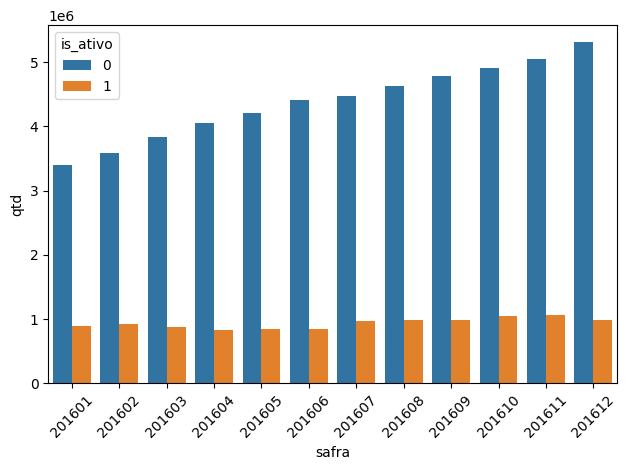

In [23]:
# Quantidade de ativos por safra -- Acumulativa
sns.barplot(
    pd_members.sort_values(by='safra', ascending=True), x="safra", y ='qtd', hue= 'is_ativo'
)
plt.xticks(rotation=45)
plt.tight_layout()
# 4.294.184             

# CRIAÇÃO DA TARGET E NOVAS FEATURES
Relembrando o problema:

*"Sabendo que existe a seguinte ação de retenção para clientes: Quando detectamos que um cliente não renova a assinatura, oferecemos 3 meses grátis. Porém, identificamos que essa ação é muito reativa e entendemos que uma abordagem proativa seria mais efetiva. Sendo assim, é proposto que você crie um modelo classificador para **prever clientes que serão churn 3 meses no futuro (ou seja, clientes que possuem assinatura ativa no período analisado e 3 meses depois desse período ele não é mais ativo, ou porque cancelou ou não renovou a assinatura)** e indique os clientes que serão direcionados para a ação de forma proativa."*

Sendo assim, irei seguir da seguinte forma para criação da Target após análise das bases:

* Após diversas análises no comportamento das bases, é percebido que tanto quando um cliente cancela ou quando um cliente não renova, o campo is_ativo =1 se torna 0 na próxima safra. Por tanto, a minha target será criada usando a função lead(3) com uma window function particionada por cliente (msno) e ordenada por safra. Assim conseguirei saber se 3 meses no futuro o cliente é um churn;
* Junto da target, já irei criar algumas features para o modelo, trazendo informações do último pagamento antes daquela safra para ser usada no modelo. Hipótese de que o quanto o cliente pagou no último plano pode ter levado ao churn
* Outra hipótese é de que o churn pode ser predito verificando o comportamental do cliente no tempo: se ele está ouvindo menos musicas completas; quanto ele diminuiu de um mês para o outro até o churn, etc. Testarei isso na etapa de fetature selection. Vou criar features com base em 3 e 6 meses para testar, se tiver multicolinariedade grande entre as duas, descartarei uma delas após análise com a variavel target.
* Outra hipótese que tenho é que se uma pessoa tem uma relação longa com a empresa, é mais difícil de ter churn, por isso criarei fetatures que digam sobre tempo de registro, tempo de plano, etc.
* Essas hipóteses eu irei testar no outro notebook, onde vou fazer o modelo.

Churn: 14% de churn, ou seja, uma classe desbalanceada. na safra de janeiro e fevereiro foram onde teve mais churn (20%). Teremos que usar alguma tecnica para balancear na hora de treinar o modelo. Seja oversample, undersample ou usar a regulação de classes (class weights). Pretendo usar a regulação de classes dos modelos baseadas em arvores.




In [24]:
from pyspark.sql.window import Window
win_msno_safra = (
    Window
    .partitionBy("msno")
    .orderBy("safra")
)

members_churn = (
    members
    .withColumn("is_ativo_3_meses", lead(col("is_ativo"),3).over(win_msno_safra))
    .withColumn("churn", expr("case when (is_ativo_3_meses = 0) then 1 else 0 end ") )
    .filter(col("is_ativo")==1)
    .filter(col("safra")<=201609)
    ## dropando a coluna auxiliar para criar o churn e dropar também a gender porque além de ser uma variavel descriminatória, tem boa parte dos registros nula
    .drop(col("is_ativo_3_meses"), col("gender"))
)

members_churn.groupBy("safra").agg(sum("churn")/count("churn")).show()

+------+---------------------------+
| safra|(sum(churn) / count(churn))|
+------+---------------------------+
|201607|        0.10874995867495371|
|201605|        0.11798463608084712|
|201602|        0.20116739061295086|
|201606|        0.11486783984546992|
|201609|        0.13007863530669786|
|201608|          0.125614520268844|
|201604|        0.10669520722974152|
|201601|        0.20620415163003297|
|201603|        0.15679899409281925|
+------+---------------------------+



In [25]:
win_partition_msno = (
    Window
    .partitionBy("msno")
    .orderBy("safra")
)

cond = expr("m.msno == t.msno and t.safra<= m.safra")

members_transaction_churn = (
    members_churn.alias("m")
    .join(transactions.alias("t"),cond, 'inner')
    .drop(col("t.safra"),col("t.msno"))
    .withColumn("transacao_mais_perto_safra", expr("row_number() over (partition by msno, safra order by transaction_date desc)"))
    .withColumn("qtd_pagamentos", expr("row_number() over (partition by msno, safra order by transaction_date asc)"))
    .filter(col("transacao_mais_perto_safra") == 1 ) ## filtra transação mais perto da safra
    #### FILTROS PARA A A BASE FINAL
    .filter("safra <= 201609") ## safras que não possuem target, pois o maximo de transação que temos é de 
    .filter("is_ativo = 1") ## para se tornar churn, o cliente tem que estar ativo 3 meses antes
    #### estou dropando a coluna is_cancel porque ela é uma das causas do churn e pode ludibriar o modelo
    .drop(
        col("is_cancel")
        ,col("transacao_mais_perto_safra")
    )
)

In [26]:
members_transaction_churn.show(2, vertical = True)

-RECORD 0--------------------------------------
 msno                   | ++4RuqBw0Ss6bQU4o... 
 safra                  | 201601               
 registration_init_time | 20140714             
 city                   | 1                    
 bd                     | 0.0                  
 registered_via         | 7                    
 is_ativo               | 1                    
 faixa_idade            | 1                    
 churn                  | 0                    
 plan_list_price        | 149.0                
 payment_plan_days      | 30                   
 actual_amount_paid     | 149.0                
 transaction_date       | 20160113             
 membership_expire_date | 20160213             
 qtd_pagamentos         | 13                   
-RECORD 1--------------------------------------
 msno                   | ++4RuqBw0Ss6bQU4o... 
 safra                  | 201602               
 registration_init_time | 20140714             
 city                   | 1             

In [27]:
## CRIANDO FEATURES
win_partition_msno = (
    Window
    .partitionBy("msno")
    .orderBy("safra")
)

    ## essa função tem como objetivo criar features para ser usadas no modelo. 
    ## A ideia é criar comparações para entender o comportamento de clientes que são churn,
    ## como varia a quantidade ouvida por mês até o churn, por isso estou criando features comparativas com o mês de safra, como comparar a media dos 3 ultimos meses com o mes atual. 

def newFeatures(df,cols):

    for c in cols:
        df = (
            df
            .withColumn(f"media_3_ant_meses_{c}", coalesce(avg(col(c)).over(win_partition_msno.rowsBetween(-3, -1)),col(c)))
            .withColumn(f"media_6_ant_meses_{c}", coalesce(avg(col(c)).over(win_partition_msno.rowsBetween(-6, -1)),col(c)))
            
            .withColumn(f"diff_ultimo_mes_{c}", coalesce(col(c) - lag(col(c),1).over(win_partition_msno),lit(0)))
            .withColumn(f"diff_mesAtual_media3AntMeses_{c}", coalesce( (col(c) - col(f"media_3_ant_meses_{c}")),col(c)))
            .withColumn(f"diff_mesAtual_media6AntMeses_{c}", coalesce( (col(c) - col(f"media_6_ant_meses_{c}")),col(c)))
            
            .withColumn(f"diff_perc_ultimo_mes_{c}", coalesce( (col(f"diff_ultimo_mes_{c}")/col(c)),lit(0)))
            .withColumn(f"diff_perc_mesAtual_media3AntMeses_{c}", coalesce(col(f"diff_mesAtual_media3AntMeses_{c}")/col(c),lit(0)))
            .withColumn(f"diff_perc_mesAtual_media6AntMeses_{c}", coalesce(col(f"diff_mesAtual_media6AntMeses_{c}")/col(c),lit(0)))
            .drop(
                col(f"media_3_ant_meses_{c}")
                , col(f"media_6_ant_meses_{c}")
                , col(f"diff_ultimo_mes_{c}")
                , col(f"diff_mesAtual_media3AntMeses_{c}")
                , col(f"diff_mesAtual_media6AntMeses_{c}")
            )
        )
    return df

cols_userlogs = [
 'num_25',
 'num_50',
 'num_75',
 'num_985',
 'num_100',
 'num_unq',
 'total_secs'
]

user_logs_newFeatures = newFeatures(df = user_logs, cols =cols_userlogs)



In [28]:
user_logs_newFeatures.show(5,vertical = True)

-RECORD 0------------------------------------------------------------
 msno                                         | ++0O0Bq04sB/9ZcOS... 
 safra                                        | 201501               
 num_25                                       | 2.0                  
 num_50                                       | 0.0                  
 num_75                                       | 0.0                  
 num_985                                      | 0.0                  
 num_100                                      | 2.0                  
 num_unq                                      | 4.0                  
 total_secs                                   | 523.988              
 diff_perc_ultimo_mes_num_25                  | 0.0                  
 diff_perc_mesAtual_media3AntMeses_num_25     | 0.0                  
 diff_perc_mesAtual_media6AntMeses_num_25     | 0.0                  
 diff_perc_ultimo_mes_num_50                  | 0.0                  
 diff_perc_mesAtual_

Tomei a decisão de que se a pessoa não aparece na user_logs, é sinal que ela não ouviu nada no último mês. Portanto, usarei um left join e preencherei com 0 os que não tiverem correspondência

In [29]:
transactions_members_userLogs_newFeatures = (
    members_transaction_churn
    .join(user_logs_newFeatures,["msno","safra"],"left")
    .fillna(0)
    ### adicionando algumas outras features que acho que podem ajudar o modelo
    .withColumn("safra_date", to_date(concat(col("safra"),lit("01")),"yyyyMMdd"))
    .withColumn("registration_init_time", to_date(col("registration_init_time"),"yyyyMMdd"))
    .withColumn("transaction_date", to_date(col("transaction_date"),"yyyyMMdd"))
    .withColumn("membership_expire_date", to_date(col("membership_expire_date"),"yyyyMMdd"))
    .withColumn("meses_resgistro_ultimoPagamento", months_between(col("transaction_date"),col("registration_init_time")))
    .withColumn("meses_resgistro_safra", months_between(col("safra_date"),col("registration_init_time")))
)

In [30]:
#transactions_members_userLogs_newFeatures.write.mode('overwrite').parquet('/kaggle/working/tabela_completa_v3.parquet')

# Descobrindo o quanto um cliente que fica ativo por 1 ano traz de receita
Vou usar essa informação para levantar o quanto o modelo trará de ganhos financeiros.

In [31]:
df_members = (
    members
    .filter(col("is_ativo")==1)
    .withColumn("rn", expr("row_number() over( partition by msno order by safra)"))
    .filter("rn == 12")
    .select(
        "msno"
    )
    .distinct()
)

df_transactions = (
    transactions
    .filter("safra between 201601 and 201612")
    .select(
        "msno"
        ,"actual_amount_paid"
    )
)

rent = (
    df_members
    .join(
        df_transactions,["msno"],"inner"
    )
    .agg(
        sum("actual_amount_paid").alias("total")
        , count("msno").alias("transacao")
        , countDistinct("msno").alias("cliente2")
    )
    .withColumn("valor_por_cliente", col("total")/col("cliente2"))
)

rent.show()



+------------+---------+--------+-----------------+
|       total|transacao|cliente2|valor_por_cliente|
+------------+---------+--------+-----------------+
|7.82143438E8|  5614108|  507386|1541.515607446796|
+------------+---------+--------+-----------------+

